# Grouping

In [5]:
import pandas as pd  # load pandas and call it pd

In [6]:
df_moldova = pd.read_csv("C:/Users/harttu25h/Downloads/introduction-to-data-engineering-main-week-05-materials-maddison_by_country/introduction-to-data-engineering-main-week-05-materials-maddison_by_country/week-05/materials/maddison_by_country/Moldova.csv")  # read Moldova's GDP history into a table

In [7]:
df_moldova.head(3)  # show the first 3 rows

,Entity,Code,Year,GDP,GDP (Annotations)
0,Moldova,MDA,1973,32094175685,NaN
1,Moldova,MDA,1980,36278212375,NaN
2,Moldova,MDA,1981,38401934720,NaN


In [8]:
df_moldova["GDP"].max()  # largest GDP value

np.int64(44850495812)

In [9]:
df_moldova["Year"].max()  # latest year in the table

np.int64(2022)

In [10]:
df_moldova["Year"].idxmax()  # row number of that latest year

43

In [11]:
df_moldova[df_moldova["Year"] == 1980]  # keep only the row for 1980

,Entity,Code,Year,GDP,GDP (Annotations)
1,Moldova,MDA,1980,36278212375,NaN


In [12]:
df_moldova[df_moldova["Year"] == 1980]  # keep only the row for 1980

,Entity,Code,Year,GDP,GDP (Annotations)
1,Moldova,MDA,1980,36278212375,NaN


In [13]:
df_moldova.loc[43]  # select the row at index 43

Entity                   Moldova
Code                         MDA
Year                        2022
GDP                  23827554273
GDP (Annotations)            NaN
Name: 43, dtype: object

In [14]:
df_moldova.loc[df_moldova["Year"].idxmax()]  # select the row with the latest year

Entity                   Moldova
Code                         MDA
Year                        2022
GDP                  23827554273
GDP (Annotations)            NaN
Name: 43, dtype: object

In [15]:
from pathlib import Path  # Path is used to point at files and folders

In [16]:
folder = Path("C:/Users/harttu25h/Downloads/introduction-to-data-engineering-main-week-05-materials-maddison_by_country/introduction-to-data-engineering-main-week-05-materials-maddison_by_country/week-05/materials/maddison_by_country/")  # folder that holds one CSV per country

In [17]:
folder.glob("*.csv")  # match every CSV file in that folder

In [18]:
dataframes = []  # list that will hold one table per country
for file in folder.glob("*.csv"):  # take each CSV file in turn
    #print(file)  # unused: would print the file path
    dataframes.append(pd.read_csv(file))  # read the file and add its table to the list

In [19]:
len(dataframes)  # how many country tables were loaded

177

In [20]:
dataframes[-1]  # show the last country table in the list

,Entity,Code,Year,GDP,GDP (Annotations)
0,Zimbabwe,ZWE,1950,3186969531,NaN
1,Zimbabwe,ZWE,1951,3396532996,NaN
2,Zimbabwe,ZWE,1952,3555366657,NaN
3,Zimbabwe,ZWE,1953,3864261086,NaN
4,Zimbabwe,ZWE,1954,4071253000,NaN
...,...,...,...,...,...
68,Zimbabwe,ZWE,2018,26786271482,NaN
69,Zimbabwe,ZWE,2019,25146416205,NaN
70,Zimbabwe,ZWE,2020,23178707175,NaN
71,Zimbabwe,ZWE,2021,25140088767,NaN


In [21]:
df = pd.concat(dataframes)  # stack every country table into one table

In [22]:
df.to_csv("C:/Users/harttu25h/Downloads/all_countries.csv")  # save that combined table as a CSV file

In [23]:
df.groupby("Entity")["GDP"].min()  # smallest GDP for each country

Entity
Afghanistan       7919856426
Albania            428733000
Algeria           1841965000
Angola            6905244023
Argentina          849594000
                   ...      
World          1175113811058
Yemen             6936333035
Yugoslavia        7245256000
Zambia            2690862000
Zimbabwe          3186969531
Name: GDP, Length: 177, dtype: int64

In [24]:
df.groupby("Entity")["GDP"].idxmin()  # row index of each country's smallest GDP

Entity
Afghanistan    44
Albania         0
Algeria         0
Angola          0
Argentina       0
               ..
World           0
Yemen           0
Yugoslavia      0
Zambia          0
Zimbabwe        0
Name: GDP, Length: 177, dtype: int64

In [25]:
df.loc[df.groupby("Entity")["GDP"].idxmin()].head(2)  # rows for each country's smallest GDP; show the first 2

,Entity,Code,Year,GDP,GDP (Annotations)
44,Afghanistan,AFG,1994,7919856426,NaN
44,Albania,ALB,1988,12296424628,NaN


Find for each country min and max GDP and put them together


In [26]:
df_min = df.loc[df.groupby("Entity")["GDP"].idxmin()]  # one row per country: the year GDP was lowest
df_min["Comment"] = "Min Year"  # label those rows as the minimum
df_max = df.loc[df.groupby("Entity")["GDP"].idxmax()]  # one row per country: the year GDP was highest
df_max["Comment"] = "Max Year"  # label those rows as the maximum

In [27]:
pd.concat([df_min, df_max])  # stack the lowest-GDP rows and the highest-GDP rows

,Entity,Code,Year,GDP,GDP (Annotations),Comment
44,Afghanistan,AFG,1994,7919856426,NaN,Min Year
44,Albania,ALB,1988,12296424628,NaN,Min Year
44,Algeria,DZA,1991,121105141795,NaN,Min Year
44,Angola,AGO,1994,10760814258,NaN,Min Year
44,Argentina,ARG,1940,93982977000,NaN,Min Year
...,...,...,...,...,...,...
48,Vietnam,VNM,1995,160152275679,NaN,Max Year
48,Yemen,YEM,1998,65613152856,NaN,Max Year
48,Yugoslavia,OWID_YGS,1970,124753920000,NaN,Max Year
48,Zambia,ZMB,1998,13130968549,NaN,Max Year


In [28]:
df_min_max = df.groupby("Entity")["Year"].agg(["min","max"])  # earliest and latest year for each country

In [29]:
df_min_max["min_max_range"] = df_min_max["max"] - df_min_max["min"]  # years between each country's earliest and latest year

In [30]:
#df_min_max.drop(columns= ["span"],inplace=True)  # unused: would delete a column named span

In [31]:
df_min_max.head(3)  # show the first 3 countries

,min,max,min_max_range
Entity,,,
Afghanistan,1950,2022,72
Albania,1870,2022,152
Algeria,1820,2022,202


In [32]:
df_min_max.loc[df_min_max["min_max_range"].idxmax()]  # country whose data covers the longest stretch of years

min                 1
max              2022
min_max_range    2021
Name: Belgium, dtype: int64

In [33]:
df.loc[df["Entity"] == "Belgium"]  # keep only Belgium's rows

,Entity,Code,Year,GDP,GDP (Annotations)
0,Belgium,BEL,1,286800000,NaN
1,Belgium,BEL,1500,3273200000,NaN
2,Belgium,BEL,1600,4052800000,NaN
3,Belgium,BEL,1700,4384000000,NaN
4,Belgium,BEL,1820,8097372000,NaN
...,...,...,...,...,...
177,Belgium,BEL,2018,462533269863,NaN
178,Belgium,BEL,2019,472897988852,NaN
179,Belgium,BEL,2020,447544069854,NaN
180,Belgium,BEL,2021,474995824355,NaN


# Merge

In [34]:
import pandas as pd  # load pandas again

url = "https://raw.githubusercontent.com/jennybc/gapminder/main/inst/extdata/gapminder.tsv"  # web address of the Gapminder table

df_gap = pd.read_csv(url, sep="\t")  # read that tab-separated file

In [37]:
df_mad = df  # second name for the combined Maddison table

In [44]:
df_mad.head(3)  # show the first 3 Maddison rows

,Country,Code,Year,GDP_total,GDP (Annotations)
0,Afghanistan,AFG,1950,9421400000,NaN
1,Afghanistan,AFG,1951,9692280000,NaN
2,Afghanistan,AFG,1952,10017325000,NaN


In [45]:
df_mad.rename(columns= { "Entity" : "Country", "GDP" : "GDP_total" } ,inplace = True )  # rename Maddison columns so they can be matched with Gapminder

In [51]:
df_gap.rename(columns= { "country" : "Country", "year" : "Year", "pop" : "Pop", "gdpPercap":"GDP_Percap"  } ,inplace = True )  # rename Gapminder columns to the same style

In [52]:
df_mad = df_mad[["Country",	"Year",	"GDP_total"]]	  # keep only country, year, and total GDP

In [54]:
df_gap = df_gap[["Country",	"Year",	"Pop", "GDP_Percap" ]]	  # keep country, year, population, and GDP per person

In [55]:
df_gap.columns  # list the Gapminder column names

Index(['Country', 'Year', 'Pop', 'GDP_Percap'], dtype='str')

In [56]:
df_mad.columns  # list the Maddison column names

Index(['Country', 'Year', 'GDP_total'], dtype='str')

In [61]:
df_gap["GDP_total"] = df_gap["Pop"] * df_gap["GDP_Percap"]  # total GDP is population times GDP per person

In [68]:
df_gap["GDP_total"] = df_gap["GDP_total"].round(-4).astype(int)  # round total GDP to the nearest 10000 and store it as a whole number

In [69]:
df_gap.head(3)  # show the first 3 Gapminder rows

,Country,Year,Pop,GDP_Percap,GDP_total
0,Afghanistan,1952,8425333,779.445314,6567090000
1,Afghanistan,1957,9240934,820.853030,7585450000
2,Afghanistan,1962,10267083,853.100710,8758860000


In [70]:
df_mad.head(3)  # show the first 3 Maddison rows

,Country,Year,GDP_total
0,Afghanistan,1950,9421400000
1,Afghanistan,1951,9692280000
2,Afghanistan,1952,10017325000


df_mad.merge(df_gap, on = ["Country"] )  # would join the tables on country only, repeating every year combination

In [83]:
df_mad.rename(columns={"GDP_total":"GDP_mad"}, inplace= True)  # name Maddison GDP so it stays separate after the join
df_gap.rename(columns={"GDP_total":"GDP_gap"}, inplace= True)  # name Gapminder GDP so it stays separate after the join
#df_gap.drop(columns=["GDP_Percap"], inplace= True)  # unused: would remove GDP per person

In [85]:
df_gap_mad = df_mad.merge(df_gap, on = ["Country", "Year"] )  # keep rows where both country and year match

In [88]:
df_gap_mad["GDP_mad"] = df_gap_mad["GDP_mad"] / 1_000_000_000  # Maddison GDP in billions
df_gap_mad["GDP_gap"] = df_gap_mad["GDP_gap"] / 1_000_000_000  # Gapminder GDP in billions

In [97]:
df_gap_mad.head(3)  # show the first 3 joined rows

,Country,Year,GDP_mad,Pop,GDP_gap,GDP_diff
0,Afghanistan,1952,10.017325,8425333,6.56709,-3.450235
1,Afghanistan,1957,11.578973,9240934,7.58545,-3.993523
2,Afghanistan,1962,13.367634,10267083,8.75886,-4.608774


In [99]:
df_gap_mad["GDP_diff"] = df_gap_mad["GDP_gap"] - df_gap_mad["GDP_mad"]  # Gapminder GDP minus Maddison GDP
df_gap_mad["GDP_diff_perc"] = ( ( df_gap_mad["GDP_gap"] - df_gap_mad["GDP_mad"] ) / df_gap_mad["GDP_mad"] ) * 100  # that difference as a percent of the Maddison GDP

In [103]:
df_gap_mad  # show the full joined table

,Country,Year,GDP_mad,Pop,GDP_gap,GDP_diff,GDP_diff_perc
0,Afghanistan,1952,10.017325,8425333,6.56709,-3.450235,-34.442678
1,Afghanistan,1957,11.578973,9240934,7.58545,-3.993523,-34.489440
2,Afghanistan,1962,13.367634,10267083,8.75886,-4.608774,-34.477111
3,Afghanistan,1967,14.734026,11537966,9.64801,-5.086016,-34.518848
4,Afghanistan,1972,13.170553,13079460,9.67855,-3.492003,-26.513716
...,...,...,...,...,...,...,...
1531,Zimbabwe,1987,18.469823,9216418,6.50824,-11.961583,-64.762846
1532,Zimbabwe,1992,21.133779,10704340,7.42261,-13.711169,-64.877980
1533,Zimbabwe,1997,27.012558,11404948,9.03785,-17.974708,-66.542044
1534,Zimbabwe,2002,24.872482,11926563,8.01511,-16.857372,-67.775191


<Axes: >

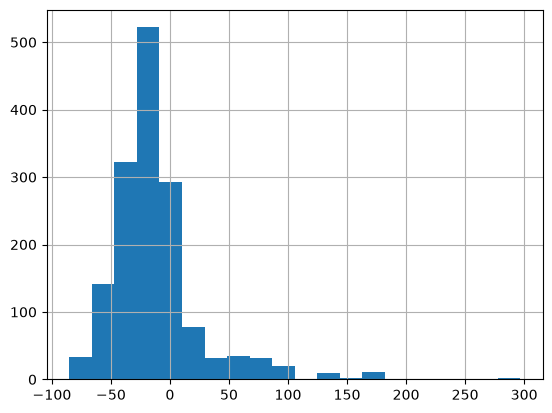

In [105]:
df_gap_mad["GDP_diff_perc"].hist(bins=20)  # histogram of the percent difference, split into 20 bars

In [100]:
df_gap_mad.loc[df_gap_mad["GDP_diff"].idxmin()]  # row where Gapminder is lowest compared with Maddison

Country                 China
Year                     2007
GDP_mad          10358.206114
Pop                1318683096
GDP_gap            6539.50093
GDP_diff         -3818.705184
GDP_diff_perc      -36.866472
Name: 299, dtype: object

In [101]:
df_gap_mad.loc[df_gap_mad["GDP_diff"].idxmax()]  # row where Gapminder is highest compared with Maddison

Country          Saudi Arabia
Year                     1982
GDP_mad            231.114687
Pop                  11254672
GDP_gap             379.20564
GDP_diff           148.090953
GDP_diff_perc       64.076825
Name: 1218, dtype: object

<Axes: >

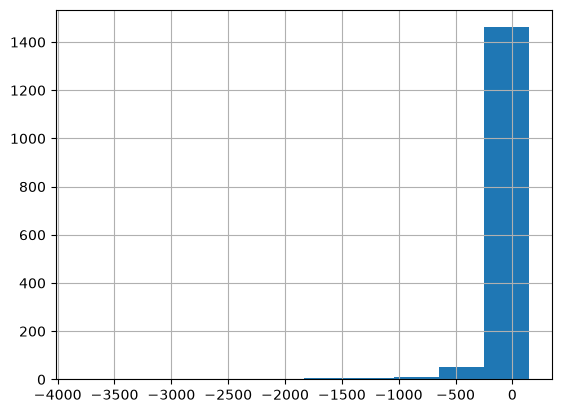

In [102]:
df_gap_mad["GDP_diff"].hist()  # histogram of the GDP difference

In [118]:
df_temp = df_mad.merge(df_gap, on = ["Country", "Year"] , how="left")  # keep every Maddison row, and attach Gapminder values when the year matches

In [ ]:
df_temp[df_temp["Country"] == "Belgium"].tail(20)  # last 20 Belgium rows, including years with no Gapminder match